# Классификация тональности текстовых отзывов
### Цель
Построить бинарный классификатор отзывов, который определяет тональность текста: **positive** или **negative**.

### Результат
- Датасет: **60 000 отзывов**, классы сбалансированы 50/50.
- Векторизация: **TF-IDF**, униграммы и биграммы, до 30 000 признаков.
- Сравнены **Logistic Regression, Linear SVM и Multinomial Naive Bayes**.
- Лучшая модель: **Linear SVM**.
- **F1 = 0.953**, Precision = 0.956, Recall = 0.950.



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import re,string,nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay,precision_score,recall_score,f1_score
import matplotlib.pyplot as plt
nltk.download('stopwords')
from nltk.corpus import stopwords
stop=set(stopwords.words('english'))
from wordcloud import WordCloud
from collections import Counter

np.random.seed(42)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Камила\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Загрузка данных

In [2]:
df=pd.read_csv('../data/texts/review.csv', sep=',')

df.head()

,review,sentiment
0,Even for a tired movie model as the nature vs....,negative
1,As others have pointed out this movie is a loa...,negative
2,"Excellent view of a mature woman, that is goin...",positive
3,I am so glad that i got a chance to see this r...,positive
4,There's more to offer in the opening of The Od...,positive


### Структура данных

- `review` — текст отзыва;
- `sentiment` — целевая переменная: `positive` / `negative`.

## 2. EDA

In [3]:
print(df.info())
print(df.sentiment.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     60000 non-null  object
 1   sentiment  60000 non-null  object
dtypes: object(2)
memory usage: 937.6+ KB
None
sentiment
negative    30000
positive    30000
Name: count, dtype: int64


Датасет не содержит пропущенных значений.

Все признаки имеют корректные типы данных.


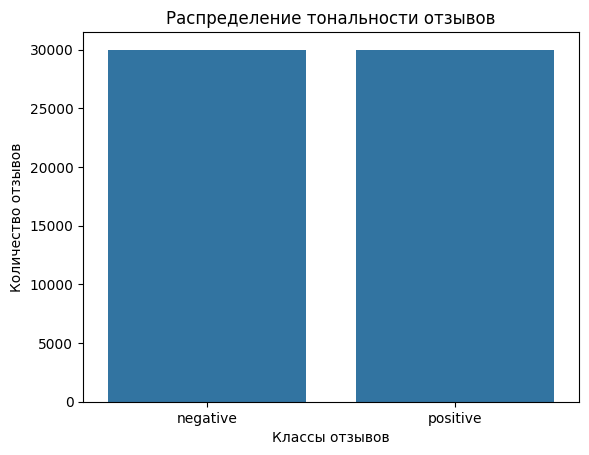

In [4]:
sns.countplot(x='sentiment', data=df)
plt.title('Распределение тональности отзывов')
plt.xlabel('Классы отзывов')
plt.ylabel('Количество отзывов')
plt.show()

**Вывод:** классы сбалансированы — по 30 000 положительных и отрицательных отзывов. Дополнительная балансировка классов не требуется.

Медианная длина отзыва: 170.0


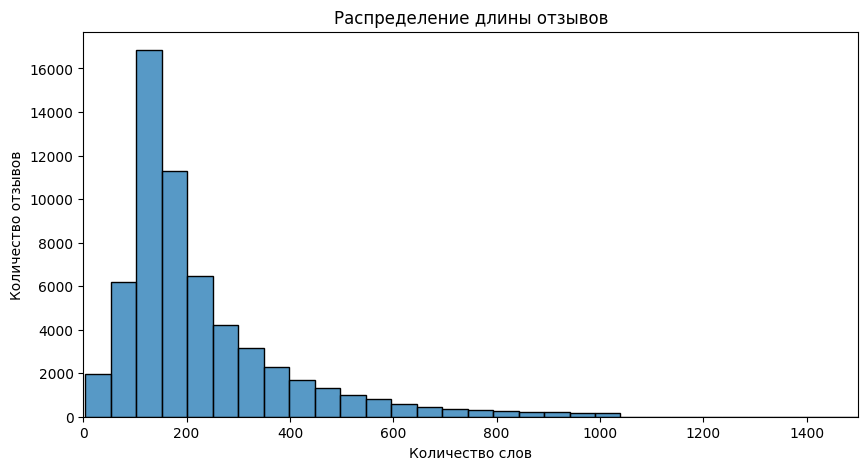

In [5]:
df['word_count'] = df['review'].apply(lambda x: len(x.split()))
print(f"Медианная длина отзыва: {df['word_count'].median()}")

plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50)
plt.title('Распределение длины отзывов')
plt.xlabel('Количество слов')
plt.ylabel('Количество отзывов')
plt.xlim(0, 1500)
plt.show()

**Вывод**: медианная длина отзыва = 170 слов. Большинство тектов имеют среднюю длину, но распределение нормальное с правосторонней асимметрией, так как встречаются длинные тексты. Необходимо применять методы векторизации текста вместо подсчёта слов.

## 3. Анализ лексики.

In [6]:
custom_stopwords = {
    'film', 'movie', 'one', 'would', 'could',
    'really', 'even', 'get', 'make', 'see',
    'also', 'first', 'people', 'much', 'like'
}

stop_words = stop.union(custom_stopwords)

In [7]:
positive_reviews = ' '.join(df[df['sentiment'] == 'positive']['review'])
negative_reviews = ' '.join(df[df['sentiment'] == 'negative']['review'])

In [8]:
def get_top_n_words(text, n=15):
    words = [word for word in text.lower().split() if word not in stop_words and word.isalpha()]
    return Counter(words).most_common(n)

In [9]:
print("Топ-15 слов в положительных отзывах:", get_top_n_words(positive_reviews))
print("Топ-15 слов в отрицательных отзывах:", get_top_n_words(negative_reviews))

Топ-15 слов в положительных отзывах: [('good', 14260), ('great', 13085), ('story', 11211), ('time', 9284), ('well', 8887), ('best', 8805), ('many', 8655), ('love', 8393), ('think', 7923), ('two', 7622), ('little', 7303), ('never', 7291), ('made', 7269), ('still', 6815), ('seen', 6785)]
Топ-15 слов в отрицательных отзывах: [('good', 13711), ('bad', 12566), ('time', 8954), ('made', 8626), ('story', 8597), ('think', 7924), ('never', 7546), ('watch', 7222), ('plot', 6959), ('know', 6913), ('many', 6800), ('ever', 6792), ('acting', 6771), ('two', 6749), ('little', 6616)]


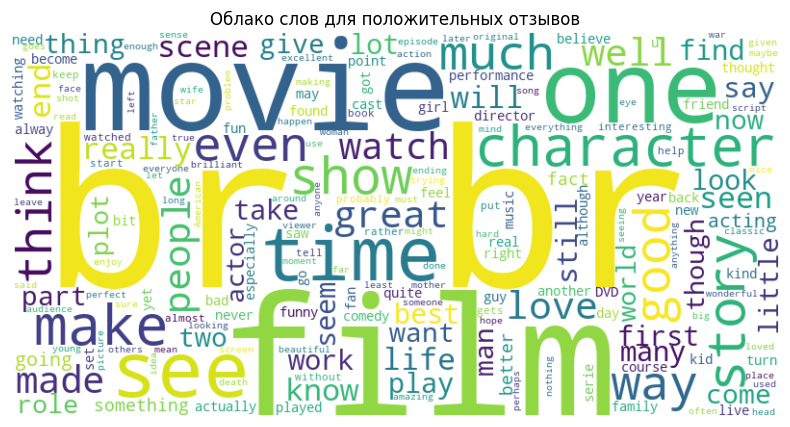

In [10]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов для положительных отзывов')
plt.show()

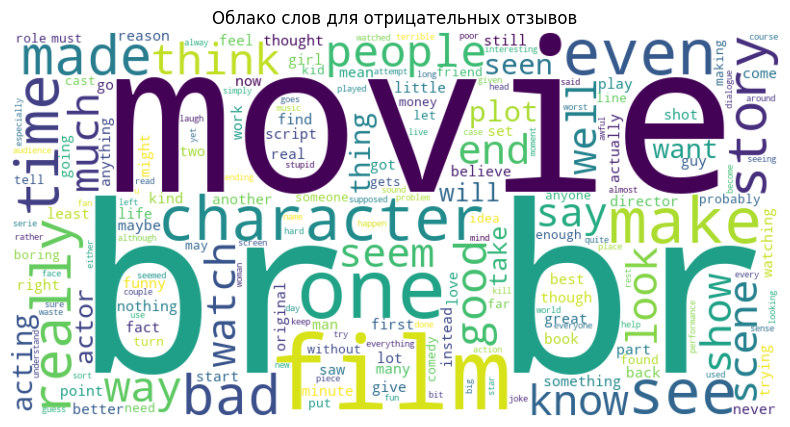

In [11]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_reviews)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов для отрицательных отзывов')
plt.show()

**Наблюдение**

И положительные, и отрицательные отзывы часто содержат такие слова, как film, movie, one, like, see. Это можно объяснить тем, что авторы отзывов так или иначе комментируют одни и те же объекты. 

В положительных отзывах чаще встречаются слова с положительной эмоциональной окраской, например great и story. В отрицательных отзывах заметно возрастает частота слова bad.

## 4. Предобработка текста

In [12]:
def clean(t):
    t=t.lower()
    t=re.sub(r'<.*?>',' ',t)
    t=re.sub(r'http\S+',' ',t)
    t=t.translate(str.maketrans('','',string.punctuation))
    t=' '.join(w for w in t.split() if w not in stop_words)
    return t
df['clean']=df.review.apply(clean)

Предварительная обработка текста включает в себя:

- перевод в нижний регистр

- удаление html-тегов

- удаление ссылок

- удаление пунктуации

- удаление стоп-слов
    

## 5. Train / test и TF-IDF

In [13]:
X_train, X_test, y_train, y_test=train_test_split(df.clean, df.sentiment, test_size=0.2, random_state=42, stratify=df.sentiment)
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=5, max_df=0.9)
Xtrain = tfidf.fit_transform(X_train)
Xtest = tfidf.transform(X_test)

Для преобразования текста использован TF-IDF. После обработки каждый отзыв представлен в виде числового вектора, который можно использовать для обучения модели.

## 6. Обучение моделей

In [14]:
models={
'LogReg' : LogisticRegression(max_iter=1000),
'LinearSVM' : LinearSVC(),
'NB' : MultinomialNB()
}
best=None;bestf=0
for n, m in models.items():
    m.fit(Xtrain, y_train)
    p = m.predict(Xtest)
    f = f1_score(y_test,p,pos_label='positive')
    print(n)
    print(classification_report(y_test,p))
    if f > bestf:
        bestf = f;best = (n,m,p)
print('Best:', best[0], bestf)


LogReg
              precision    recall  f1-score   support

    negative       0.93      0.92      0.93      6000
    positive       0.92      0.93      0.93      6000

    accuracy                           0.93     12000
   macro avg       0.93      0.93      0.93     12000
weighted avg       0.93      0.93      0.93     12000

LinearSVM
              precision    recall  f1-score   support

    negative       0.95      0.96      0.95      6000
    positive       0.96      0.95      0.95      6000

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000

NB
              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      6000
    positive       0.89      0.90      0.89      6000

    accuracy                           0.89     12000
   macro avg       0.89      0.89      0.89     12000
weighted avg       0.89      0.89      0.89     12000


**Вывод:** Linear SVM показала лучшие результаты среди рассмотренных моделей. Высокие значения Precision и Recall свидетельствуют о хорошей способности модели различать положительные и отрицательные отзывы.

## 7. Кросс-валидация

In [15]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(LinearSVC(), Xtrain, y_train, cv=5, scoring='f1_macro')
print(f"Mean CV score: {scores.mean():.4f}")

Mean CV score: 0.9431


Кросс-валидация показывает, что результат не зависит от одного конкретного разбиения train/test: средний F1 macro составляет около **0.943**.

## 8. Интерпретация признаков

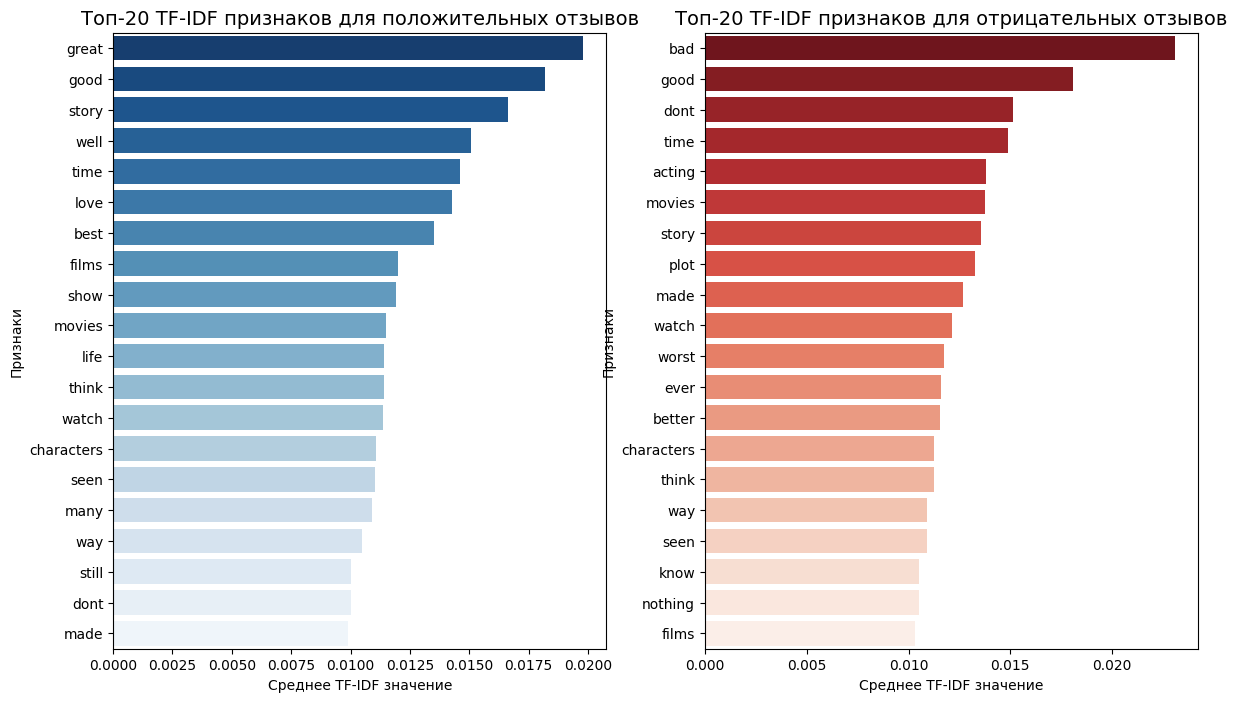

Топ-20 признаков для положительных отзывов
   feature  tfidf_mean
     great    0.019787
      good    0.018196
     story    0.016641
      well    0.015094
      time    0.014594
      love    0.014261
      best    0.013508
     films    0.012005
      show    0.011920
    movies    0.011488
      life    0.011424
     think    0.011394
     watch    0.011358
characters    0.011054
      seen    0.011046
      many    0.010884
       way    0.010486
     still    0.010035
      dont    0.010006
      made    0.009900
Топ-20 признаков для отрицательных отзывов
   feature  tfidf_mean
       bad    0.023076
      good    0.018072
      dont    0.015131
      time    0.014900
    acting    0.013816
    movies    0.013768
     story    0.013577
      plot    0.013283
      made    0.012674
     watch    0.012139
     worst    0.011757
      ever    0.011573
    better    0.011549
characters    0.011243
     think    0.011241
       way    0.010916
      seen    0.010907
      know    0.0

In [16]:
def top_tfidf_features(tfidf_vectorizer, X_train, y_train, n_features=20, figsize=(14, 8)):
    # Названия признаков
    feature_names = tfidf_vectorizer.get_feature_names_out()

    y_train = np.array(y_train)

    pos_mask = y_train == 'positive'
    neg_mask = y_train == 'negative'
    
    # TF-IDF матрицы для каждого класса и средние значения
    X_pos = X_train[pos_mask]
    X_neg = X_train[neg_mask]
    mean_pos = np.array(X_pos.mean(axis=0)).flatten()
    mean_neg = np.array(X_neg.mean(axis=0)).flatten()
    
    # топ-N признаков для каждого класса
    top_pos_indices = np.argsort(mean_pos)[::-1][:n_features]
    top_neg_indices = np.argsort(mean_neg)[::-1][:n_features]
    
    top_pos_df = pd.DataFrame({
        'feature': feature_names[top_pos_indices],
        'tfidf_mean': mean_pos[top_pos_indices]
    })
    top_neg_df = pd.DataFrame({
        'feature': feature_names[top_neg_indices],
        'tfidf_mean': mean_neg[top_neg_indices]
    })

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Положительные отзывы
    sns.barplot(data=top_pos_df, 
                x='tfidf_mean', 
                y='feature', 
                ax=axes[0], 
                palette='Blues_r', 
                hue='feature', 
                legend=False)
    axes[0].set_title(f'Топ-{n_features} TF-IDF признаков для положительных отзывов', fontsize=14)
    axes[0].set_xlabel('Среднее TF-IDF значение')
    axes[0].set_ylabel('Признаки')
    
    # Отрицательные отзывы
    sns.barplot(data=top_neg_df, 
                x='tfidf_mean', 
                y='feature', 
                ax=axes[1], 
                palette='Reds_r', 
                hue='feature', 
                legend=False)
    axes[1].set_title(f'Топ-{n_features} TF-IDF признаков для отрицательных отзывов', fontsize=14)
    axes[1].set_xlabel('Среднее TF-IDF значение')
    axes[1].set_ylabel('Признаки')
    plt.show()
    
    print("Топ-20 признаков для положительных отзывов")
    print(top_pos_df.to_string(index=False))
    print("Топ-20 признаков для отрицательных отзывов")
    print(top_neg_df.to_string(index=False))
    
    return top_pos_df, top_neg_df

top_pos, top_neg = top_tfidf_features(tfidf, Xtrain, y_train, n_features=20)

Положительные отзывы содержат эмоционально-позитивные слова (*great*, *good*, *well*, *love*, *best*) и усилители речи (*really*, *also*, *much*).
Отрицательные отзывы содержат эмоционально-негативные слова (*bad*, *don't*, *even*, *worst*).
При этом некоторые слова (*good*, *story*, *time*, *think*) встречаются в обоих классах. Это объясняется тем, что они описывают общие характеристики фильма и сами по себе не определяют тональность отзыва. Следовательно, для корректной классификации важна не только частота отдельных слов, но и их сочетания.

## 9. Матрица ошибок

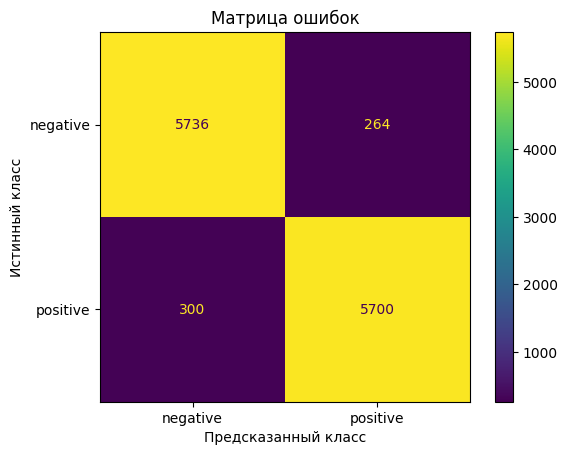

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, best[2])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()


300 позитивных отзывов были приняты за негативные и 264 негативных - за позитивные. 

Ошибки первого рода (false pozitive) могут быть вызваны отзывами, которые были написаны с сарказмом или в которых была использована нейтральная лексика в негативном ключе.

Ошибки второго рода (false negative) могли быть вызваны тем, что отзывы были наполнены критикой, но с положительным подтекстом, или сложными конструкциями с отрицаниями. 


## 10. Метрики

In [18]:
print('F1: ',f1_score(y_test, best[2], pos_label='positive'))
print('Precision: ', precision_score(y_test, best[2], pos_label='positive'))
print('Recall: ', recall_score(y_test, best[2], pos_label='positive'))

F1:  0.9528585757271816
Precision:  0.9557344064386318
Recall:  0.95


### Итог

**Linear SVM** достигла:
- **Precision = 0.956**
- **Recall = 0.950**
- **F1 = 0.953**

Все три значения выше целевых порогов проекта: Precision > 0.70, Recall > 0.70, F1 > 0.75.

## 11. Сохранение артефактов

In [19]:
import pickle
import os

# best = (название_модели, модель, предсказания)
best_name, best_model, _ = best

model_data = {
    "model_name": best_name,
    "model": best_model
}

model_path = '../models/model.pkl'
os.makedirs(os.path.dirname(model_path), exist_ok=True)
with open(model_path, "wb") as f:
    pickle.dump(model_data, f)

print("Модель сохранена в model.pkl")
print(f'\nДля загрузки модели в инференсе:')
print(f'  with open("{model_path}", "rb") as f:')
print(f'      model_data = pickle.load(f)')
print('  model = model_data["model"]')

features_data = {
    "vectorizer": tfidf,
    "stop_words": stop_words,
    "clean_func": clean
}

features_path = "../models/features.pkl"
os.makedirs(os.path.dirname(features_path), exist_ok=True)
with open(features_path, "wb") as f:
    pickle.dump(features_data, f)

print("\n Параметры сохранены в features.pkl")
print(f'\nДля загрузки в инференсе:')
print(f'  with open("{features_path}", "rb") as f:')
print(f'      features_data = pickle.load(f)')
print('  tfidf = features_data["vectorizer"]')
print('  stop_words = features_data["stop_words"]')
print('  clean = features_data["clean_func"]')

Модель сохранена в model.pkl

Для загрузки модели в инференсе:
  with open("../models/model.pkl", "rb") as f:
      model_data = pickle.load(f)
  model = model_data["model"]

 Параметры сохранены в features.pkl

Для загрузки в инференсе:
  with open("../models/features.pkl", "rb") as f:
      features_data = pickle.load(f)
  tfidf = features_data["vectorizer"]
  stop_words = features_data["stop_words"]
  clean = features_data["clean_func"]
